# AI Detector 

## 1. Imports & Config

In [26]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from datasets import load_dataset
from transformers import AutoTokenizer
from peft import AutoPeftModelForSequenceClassification
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
from sklearn.metrics import (
    classification_report,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
    auc,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)

MODEL_DIR  = "../model/output_peft"   # same as output_dir in train_peft.py
VAL_PATH   = "../../data/ml_val_clean.parquet"
TEST_PATH  = "../../data/ml_test_clean.parquet"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")

Device : cuda


## 2. Load Model & Tokenizer

In [27]:
import os

MODEL_DIR = os.path.abspath("../output_peft")

print(MODEL_DIR)
print(os.path.exists(MODEL_DIR))
print(os.listdir(MODEL_DIR))

c:\Users\OMEN\Desktop\ai-detector\model\output_peft
True
['adapter_config.json', 'adapter_model.safetensors', 'checkpoint-30918', 'checkpoint-61836', 'README.md', 'tokenizer.json', 'tokenizer_config.json', 'training_args.bin']


In [28]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR,local_files_only=True , repo_type="tokenizer")
model     = AutoPeftModelForSequenceClassification.from_pretrained(MODEL_DIR,local_files_only=True)

print("Model and tokenizer loaded.")
model     = model.to(device)
model.eval()

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-multilingual-cased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model and tokenizer loaded.


PeftModelForSequenceClassification(
  (base_model): LoraModel(
    (model): DistilBertForSequenceClassification(
      (distilbert): DistilBertModel(
        (embeddings): Embeddings(
          (word_embeddings): Embedding(119547, 768, padding_idx=0)
          (position_embeddings): Embedding(512, 768)
          (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (transformer): Transformer(
          (layer): ModuleList(
            (0-5): 6 x TransformerBlock(
              (attention): DistilBertSelfAttention(
                (q_lin): lora.Linear(
                  (base_layer): Linear(in_features=768, out_features=768, bias=True)
                  (lora_dropout): ModuleDict(
                    (default): Dropout(p=0.1, inplace=False)
                  )
                  (lora_A): ModuleDict(
                    (default): Linear(in_features=768, out_features=8, bias=False)
                  )
     

## 3. Load & Tokenise Data

In [29]:
data = load_dataset(
    "parquet",
    data_files={"validation": VAL_PATH, "test": TEST_PATH},
    columns=["text", "label", "lang"],
)

def tokenize(examples):
    tokens = tokenizer(
        examples["text"],
        truncation=True,
        padding=False,
    )
    tokens["labels"] = examples["label"]
    return tokens

data = data.map(tokenize, batched=True)

print(f"Val  : {len(data['validation']):,} samples")
print(f"Test : {len(data['test']):,} samples")

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

Map:   0%|          | 0/99152 [00:00<?, ? examples/s]

Map:   0%|          | 0/85213 [00:00<?, ? examples/s]

Val  : 99,152 samples
Test : 85,213 samples


## 4.  Get Predictions on ml_val (raw probabilities)

In [32]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer)

def get_predictions(hf_split, desc="Evaluating"):
    """Returns (true_labels, raw_preds_argmax, probabilities) as numpy arrays."""
    # keep only model input columns
    cols   = ["input_ids", "attention_mask", "labels"]
    subset = hf_split.select_columns(cols)
    subset.set_format("torch")

    loader = DataLoader(subset, batch_size=32, shuffle=False, collate_fn=data_collator)

    all_labels, all_preds, all_probs = [], [], []

    with torch.no_grad():
        for batch in tqdm(loader, desc=desc):
            input_ids      = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels         = batch["labels"]

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            probs   = torch.nn.functional.softmax(outputs.logits, dim=-1)
            preds   = outputs.logits.argmax(dim=-1)

            all_labels.extend(labels.tolist())
            all_preds.extend(preds.cpu().tolist())
            all_probs.extend(probs.cpu().numpy())

    return np.array(all_labels), np.array(all_preds), np.array(all_probs)

print('Probabilities and labels retrieved for ml_val.')

Probabilities and labels retrieved for ml_val.


## 5. Val — Baseline Report (threshold = 0.5)

In [33]:
val_labels, val_preds_raw, val_probs = get_predictions(data["validation"], "ml_val")

print("=== Classification Report ml_val — Baseline threshold (0.5) ===\n")
print(classification_report(val_labels, val_preds_raw, target_names=["Human", "AI"]))

ml_val:   0%|          | 0/3099 [00:00<?, ?it/s]

=== Classification Report ml_val — Baseline threshold (0.5) ===

              precision    recall  f1-score   support

       Human       0.99      0.81      0.89     79186
          AI       0.56      0.96      0.71     19966

    accuracy                           0.84     99152
   macro avg       0.77      0.88      0.80     99152
weighted avg       0.90      0.84      0.85     99152



## 6. Threshold Optimization on Val (Human class)

In [34]:
val_human_probs  = val_probs[:, 0]                 # P(Human)
val_bin_labels   = (val_labels == 0).astype(int)   # 1 = Human

precisions, recalls, thresholds = precision_recall_curve(val_bin_labels, val_human_probs)

f1_scores = (2 * precisions[:-1] * recalls[:-1]
             / (precisions[:-1] + recalls[:-1] + 1e-8))

# Strategy 1 — best F1
idx_f1      = np.argmax(f1_scores)
thr_best_f1 = thresholds[idx_f1]

# Strategy 2 — balanced P ≈ R ≈ 0.80
TARGET       = 0.80
idx_balanced = np.argmin(np.abs(precisions[:-1] - TARGET) + np.abs(recalls[:-1] - TARGET))
thr_balanced = thresholds[idx_balanced]

# Strategy 3 — high precision (>= 0.90)
high_prec_mask = precisions[:-1] >= 0.90
if high_prec_mask.any():
    idx_hp        = np.where(high_prec_mask)[0][np.argmax(recalls[:-1][high_prec_mask])]
    thr_high_prec = thresholds[idx_hp]
else:
    print("No threshold achieves P≥0.90 — falling back to best-F1.")
    idx_hp        = idx_f1
    thr_high_prec = thr_best_f1

idx_base = np.argmin(np.abs(thresholds - 0.5))

print("=== Threshold strategies (ml_val) ===")
print(f"  Baseline  (0.50)          — P={precisions[idx_base]:.4f} | R={recalls[idx_base]:.4f} | F1={f1_scores[idx_base]:.4f}")
print(f"  Best F1   ({thr_best_f1:.4f})   — P={precisions[idx_f1]:.4f} | R={recalls[idx_f1]:.4f} | F1={f1_scores[idx_f1]:.4f}")
print(f"  Balanced  ({thr_balanced:.4f})   — P={precisions[idx_balanced]:.4f} | R={recalls[idx_balanced]:.4f} | F1={f1_scores[idx_balanced]:.4f}")
print(f"  High Prec ({thr_high_prec:.4f})  — P={precisions[idx_hp]:.4f} | R={recalls[idx_hp]:.4f} | F1={f1_scores[idx_hp]:.4f}")

=== Threshold strategies (ml_val) ===
  Baseline  (0.50)          — P=0.9863 | R=0.8107 | F1=0.8899
  Best F1   (0.0215)   — P=0.9447 | R=0.9707 | F1=0.9575
  Balanced  (0.5378)   — P=0.9869 | R=0.8000 | F1=0.8837
  High Prec (0.0017)  — P=0.9000 | R=0.9947 | F1=0.9450


## 7. Threshold Plots

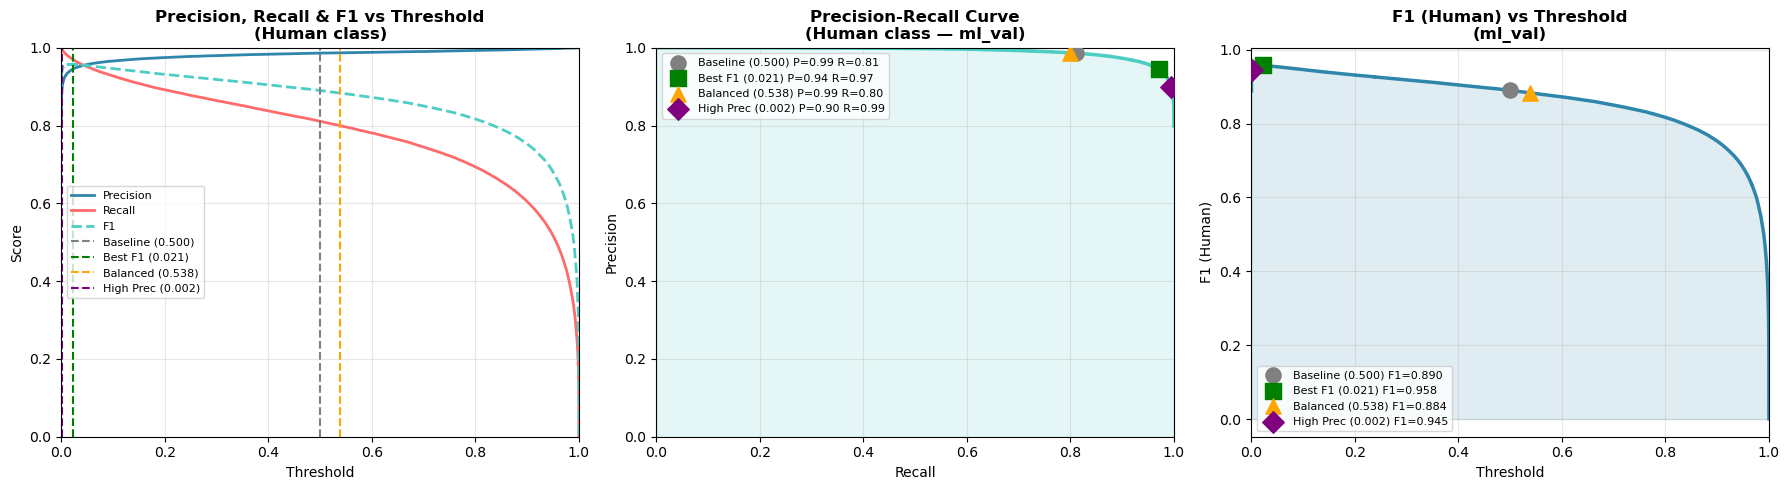


→ Choose the threshold strategy that best fits your use case:
   • Best F1   : best overall Human detection
   • Balanced  : equilibrium between Precision and Recall at 0.80
   • High Prec : minimise false Human positives (stricter)


In [35]:
strategies = [
    (idx_base,     0.5,           "Baseline",  "gray",   "o"),
    (idx_f1,       thr_best_f1,   "Best F1",   "green",  "s"),
    (idx_balanced, thr_balanced,  "Balanced",  "orange", "^"),
    (idx_hp,       thr_high_prec, "High Prec", "purple", "D"),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1 — P / R / F1 vs threshold
ax = axes[0]
ax.plot(thresholds, precisions[:-1], color="#2E86AB", lw=2, label="Precision")
ax.plot(thresholds, recalls[:-1],    color="#FF6B6B", lw=2, label="Recall")
ax.plot(thresholds, f1_scores,       color="#4ECDC4", lw=2, ls="--", label="F1")
for _, thr, label, color, _ in strategies:
    ax.axvline(thr, color=color, ls="--", lw=1.5, label=f"{label} ({thr:.3f})")
ax.set_title("Precision, Recall & F1 vs Threshold\n(Human class)", fontweight="bold")
ax.set_xlabel("Threshold"); ax.set_ylabel("Score")
ax.legend(fontsize=8, loc="center left"); ax.grid(alpha=0.3)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1])

# Plot 2 — Precision-Recall curve
ax = axes[1]
ax.plot(recalls[:-1], precisions[:-1], color="#4ECDC4", lw=2.5)
ax.fill_between(recalls[:-1], precisions[:-1], alpha=0.15, color="#4ECDC4")
for idx, thr, label, color, marker in strategies:
    ax.scatter(recalls[idx], precisions[idx], color=color, s=120, marker=marker, zorder=5,
               label=f"{label} ({thr:.3f}) P={precisions[idx]:.2f} R={recalls[idx]:.2f}")
ax.set_title("Precision-Recall Curve\n(Human class — ml_val)", fontweight="bold")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1])

# Plot 3 — F1 vs threshold
ax = axes[2]
ax.plot(thresholds, f1_scores, color="#2E86AB", lw=2.5)
ax.fill_between(thresholds, f1_scores, alpha=0.15, color="#2E86AB")
for idx, thr, label, color, marker in strategies:
    ax.scatter(thr, f1_scores[idx], color=color, s=120, marker=marker, zorder=5,
               label=f"{label} ({thr:.3f}) F1={f1_scores[idx]:.3f}")
ax.set_title("F1 (Human) vs Threshold\n(ml_val)", fontweight="bold")
ax.set_xlabel("Threshold"); ax.set_ylabel("F1 (Human)")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax.set_xlim([0, 1])

plt.tight_layout()
plt.show()

print("\n→ Choose the threshold strategy that best fits your use case:")
print("   • Best F1   : best overall Human detection")
print("   • Balanced  : equilibrium between Precision and Recall at 0.80")
print("   • High Prec : minimise false Human positives (stricter)")

## 8. Choose Final Threshold & Apply on Val

In [36]:
# ── Choose your strategy ──────────────────────────────────────────────────────
# best_threshold = thr_balanced
# best_threshold = thr_high_prec
best_threshold = thr_best_f1   # ← default

print(f"Selected threshold : {best_threshold:.4f}")

val_final_preds = np.where(val_human_probs >= best_threshold, 0, 1)

print(f"\n=== Classification Report ml_val — Threshold {best_threshold:.4f} ===\n")
print(classification_report(val_labels, val_final_preds, target_names=["Human", "AI"]))

Selected threshold : 0.0215

=== Classification Report ml_val — Threshold 0.0215 ===

              precision    recall  f1-score   support

       Human       0.94      0.97      0.96     79186
          AI       0.87      0.77      0.82     19966

    accuracy                           0.93     99152
   macro avg       0.91      0.87      0.89     99152
weighted avg       0.93      0.93      0.93     99152



## 9. Test — Predictions & Apply Threshold

In [37]:
test_labels, test_preds_raw, test_probs = get_predictions(data["test"], "ml_test")

test_human_probs = test_probs[:, 0]
test_final_preds = np.where(test_human_probs >= best_threshold, 0, 1)

print("=== Classification Report ml_test — Baseline threshold (0.5) ===\n")
print(classification_report(test_labels, test_preds_raw, target_names=["Human", "AI"]))

print(f"=== Classification Report ml_test — Threshold {best_threshold:.4f} ===\n")
print(classification_report(test_labels, test_final_preds, target_names=["Human", "AI"]))

ml_test:   0%|          | 0/2663 [00:00<?, ?it/s]

=== Classification Report ml_test — Baseline threshold (0.5) ===

              precision    recall  f1-score   support

       Human       0.89      0.48      0.63     38610
          AI       0.69      0.95      0.80     46603

    accuracy                           0.74     85213
   macro avg       0.79      0.72      0.71     85213
weighted avg       0.78      0.74      0.72     85213

=== Classification Report ml_test — Threshold 0.0215 ===

              precision    recall  f1-score   support

       Human       0.82      0.72      0.76     38610
          AI       0.79      0.87      0.82     46603

    accuracy                           0.80     85213
   macro avg       0.80      0.79      0.79     85213
weighted avg       0.80      0.80      0.80     85213



## 10. ROC & PR Curves (Val + Test)

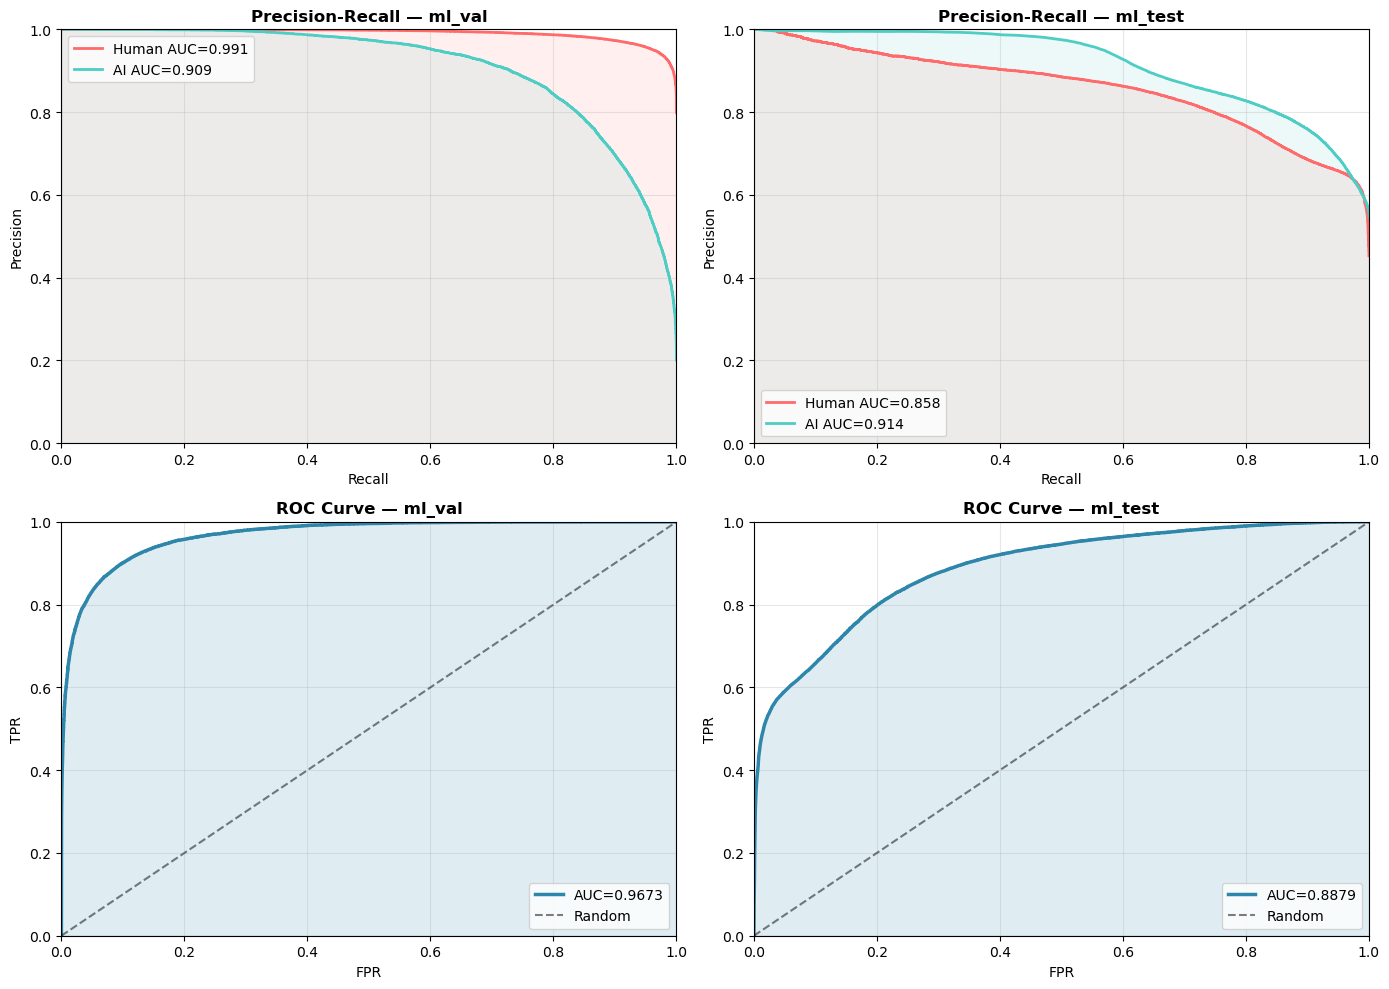

In [38]:
splits = [
    ("ml_val",  val_labels,  val_final_preds,  val_probs),
    ("ml_test", test_labels, test_final_preds, test_probs),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for col, (name, labels, preds, probs) in enumerate(splits):

    # PR Curve
    ax = axes[0][col]
    for class_idx, (lname, color) in enumerate(zip(["Human", "AI"], ["#FF6B6B", "#4ECDC4"])):
        p, r, _ = precision_recall_curve((labels == class_idx).astype(int), probs[:, class_idx])
        pr_auc  = auc(r, p)
        ax.plot(r, p, label=f"{lname} AUC={pr_auc:.3f}", lw=2, color=color)
        ax.fill_between(r, p, alpha=0.1, color=color)
    ax.set_title(f"Precision-Recall — {name}", fontweight="bold")
    ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
    ax.legend(); ax.grid(alpha=0.3)
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1])

    # ROC Curve
    ax = axes[1][col]
    fpr, tpr, _ = roc_curve(labels, probs[:, 1])
    roc_auc     = roc_auc_score(labels, probs[:, 1])
    ax.plot(fpr, tpr, label=f"AUC={roc_auc:.4f}", lw=2.5, color="#2E86AB")
    ax.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Random")
    ax.fill_between(fpr, tpr, alpha=0.15, color="#2E86AB")
    ax.set_title(f"ROC Curve — {name}", fontweight="bold")
    ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
    ax.legend(loc="lower right"); ax.grid(alpha=0.3)
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1])

plt.tight_layout()
plt.show()

## 11. Metrics by Language

In [39]:
df_val  = pd.read_parquet(VAL_PATH)
df_test = pd.read_parquet(TEST_PATH)

for name, df, labels, preds in [
    ("ml_val",  df_val,  val_labels,  val_final_preds),
    ("ml_test", df_test, test_labels, test_final_preds),
]:
    print(f"\n=== Metrics by language — {name} ===")
    langs = df["lang"].values[:len(labels)]
    for lang in sorted(df["lang"].unique()):
        mask = langs == lang
        if mask.sum() == 0:
            continue
        acc  = accuracy_score(labels[mask],  preds[mask])
        prec = precision_score(labels[mask], preds[mask], zero_division=0)
        rec  = recall_score(labels[mask],    preds[mask], zero_division=0)
        f1s  = f1_score(labels[mask],        preds[mask], zero_division=0)
        print(f"  {lang:10} | Acc={acc:.4f} | Prec={prec:.4f} | Rec={rec:.4f} | F1={f1s:.4f} | n={mask.sum():,}")


=== Metrics by language — ml_val ===
  en         | Acc=0.9388 | Prec=0.8467 | Rec=0.8477 | F1=0.8472 | n=49,998
  fr         | Acc=0.9235 | Prec=0.8991 | Rec=0.7016 | F1=0.7881 | n=49,154

=== Metrics by language — ml_test ===
  en         | Acc=0.7806 | Prec=0.7496 | Rec=0.8623 | F1=0.8020 | n=71,541
  fr         | Acc=0.8958 | Prec=0.9738 | Rec=0.8774 | F1=0.9231 | n=13,672
